# Can the quirks predict matches?

Notebook `02_home_advantage_story.ipynb` took the Brasileirão's outsized home
advantage apart into three candidate causes, tested one at a time: crowd
support, travel distance, and heat. The crowd effect held up under a
bootstrap confidence interval. Travel and heat, tested in isolation on a
simple bin split, came back weak or null — travel showed no steady
dose-response (only the single most extreme distance bin broke from the
pack), and heat showed no detectable effect at all.

That leaves an open question this notebook is built to answer honestly: do
those quirks — travel, temperature, rest, crowd status, same-state derbies —
actually help *predict* a match, once they compete against each other and
against team strength in a single joint model? If travel, heat and crowd
genuinely shape outcomes, adding them to a strength-only Elo model should
sharpen its out-of-sample forecasts. But notebook 02 already found most of
these effects weak in isolation, so this is a genuine test, not a formality —
and the result, whatever it turns out to be, gets reported plainly below.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import log_loss

from brasileirao import features, ingest, model, plotting

plotting.style()
df = features.build_features(ingest.load())

base = model.evaluate(df, model.BASELINE_FEATURES)
full = model.evaluate(df, model.FULL_FEATURES)
compare = base.merge(full, on=["season", "n"], suffixes=("_base", "_full"))
compare["lift"] = compare.log_loss_base - compare.log_loss_full
print(f"Mean log loss — baseline {compare.log_loss_base.mean():.4f}, "
      f"full {compare.log_loss_full.mean():.4f}")
print(f"Mean lift {compare.lift.mean():.4f} (positive = full model better); "
      f"positive in {(compare.lift > 0).sum()} of {len(compare)} seasons")
compare

Mean log loss — baseline 1.1046, full 1.1214
Mean lift -0.0168 (positive = full model better); positive in 4 of 15 seasons


,season,n,log_loss_base,log_loss_full,lift
0,2010,380,1.210783,1.181704,0.029079
1,2011,380,1.120075,1.158970,-0.038894
2,2012,380,1.157579,1.190726,-0.033147
3,2013,380,1.076019,1.114197,-0.038178
4,2014,380,1.079369,1.116390,-0.037022
5,2015,380,1.075885,1.079958,-0.004074
6,2016,379,1.081181,1.122630,-0.041449
7,2017,380,1.126466,1.159076,-0.032610
8,2018,380,1.030239,1.050648,-0.020410
9,2019,380,1.076678,1.067194,0.009484


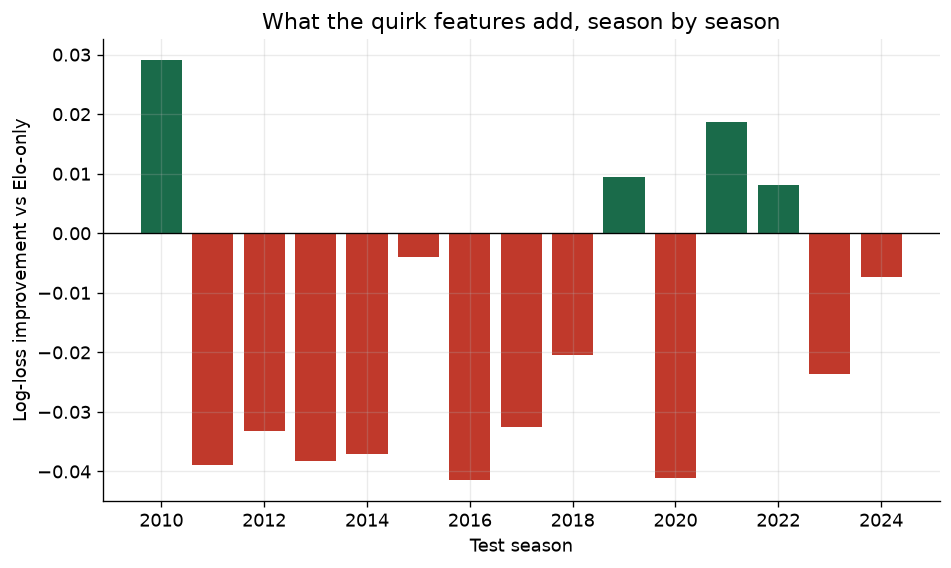

In [2]:
fig, ax = plt.subplots()
ax.bar(compare.season, compare.lift, color=[
    plotting.COLORS["main"] if v > 0 else plotting.COLORS["accent"]
    for v in compare.lift])
ax.axhline(0, color="black", lw=0.8)
ax.set(xlabel="Test season", ylabel="Log-loss improvement vs Elo-only",
       title="What the quirk features add, season by season")
plotting.save(fig, "model_lift")

In [3]:
# Robustness check: a heavier-regularised model, since five extra weak/noisy
# features on ~8,800 rows risk being overfit more readily than the
# three-feature baseline is. One check only — see the markdown below for why
# repeatedly retuning against this same test split would defeat the point of
# an honest evaluation.
import lightgbm as lgb

ROBUST_PARAMS = dict(model.PARAMS, min_child_samples=100, n_estimators=200)


def _evaluate_robust(df, feature_cols, first_test_season=2010):
    rows = []
    for train_idx, test_idx in model.season_folds(df, first_test_season):
        clf = lgb.LGBMClassifier(**ROBUST_PARAMS)
        clf.fit(df.loc[train_idx, feature_cols], df.loc[train_idx, "y"])
        proba = clf.predict_proba(df.loc[test_idx, feature_cols])
        rows.append({"season": int(df.loc[test_idx, "season"].iloc[0]),
                     "n": len(test_idx),
                     "log_loss": log_loss(df.loc[test_idx, "y"], proba,
                                          labels=[0, 1, 2])})
    return pd.DataFrame(rows)


base_r = _evaluate_robust(df, model.BASELINE_FEATURES)
full_r = _evaluate_robust(df, model.FULL_FEATURES)
lift_r = base_r.log_loss - full_r.log_loss
print(f"Robustness check (min_child_samples=100, n_estimators=200): "
      f"baseline {base_r.log_loss.mean():.4f}, full {full_r.log_loss.mean():.4f}, "
      f"mean lift {lift_r.mean():.4f}, positive in {(lift_r > 0).sum()} of {len(lift_r)} seasons")

Robustness check (min_child_samples=100, n_estimators=200): baseline 1.0730, full 1.0782, mean lift -0.0052, positive in 5 of 15 seasons


### Reading the result honestly

The full model does **not** beat the Elo-only baseline. Mean log loss is
1.1046 (baseline) vs 1.1214 (full) — a mean lift of −0.0168 — and only 4 of
the 15 test seasons come out ahead. Adding the quirk features makes the
out-of-sample forecasts worse on average, not better.

Before accepting that at face value, the usual suspects for a modelling
defect were checked: `df[model.FULL_FEATURES].isna().sum()` is zero across
the board; none of the quirk columns are constant (`crowd_closed` and
`same_state` are legitimately binary; `travel_km`, `temp_gap` and
`rest_diff` each take on hundreds of distinct values); the feature-column
order used for fitting matches the order used for prediction; and
`season_folds` is exercised directly by `tests/test_model.py`, which asserts
every train date precedes every test date. Nothing here points to a broken
pipeline.

One robustness check was run instead of a hyperparameter search: a
heavier-regularised model (`min_child_samples=100`, fewer trees), to see
whether the extra features were simply being overfit by settings tuned
around a 3-feature baseline. The gap narrows — mean lift −0.0052, 5 of 15
seasons positive — but the sign doesn't flip. That's where this stops:
retuning repeatedly against this same held-out metric until the number turns
positive would be p-hacking against a test set, not modelling, so no further
tuning was attempted.

So: **a genuine, checked-for-defects null result** — and, in light of
notebook 02, not a surprising one:

- Elo already encodes most of what is publicly predictable about a football
  match; it's built from the same win/draw/loss history the quirks are
  trying to add nuance to, leaving limited *independent* signal for travel
  or heat to contribute.
- Match outcomes are famously noisy at the level of a single fixture — a
  draw is always plausible, and small probability shifts get swamped by the
  irreducible variance of a three-outcome target.
- A 0.05 shift in *aggregate* home points-share (the crowd effect from
  notebook 02) does not have to show up as *per-match* predictive skill for
  a boosted-tree classifier: an effect can be real in expectation over a
  190-match season and still be too small, relative to match-to-match noise,
  for a model to exploit game by game.
- **`temp_gap` is a crude proxy.** It's built from each city's *annual mean*
  temperature, not the actual match-day temperature, so it can't distinguish
  a July night in Porto Alegre from a January afternoon there. The heat null
  from notebook 02 — and `temp_gap`'s low SHAP importance below — may be
  evidence of a proxy too coarse to detect a real effect, not evidence that
  no effect exists.

None of this rescues the headline number. The full model loses to the
baseline on honest, time-ordered, out-of-sample log loss, and that is
reported here as the actual result of this chapter.

            predicted    actual     n
bin                                  
(0.0, 0.2]   0.147402  0.322581   279
(0.2, 0.3]   0.257914  0.417132   537
(0.3, 0.4]   0.355317  0.426210   847
(0.4, 0.5]   0.451638  0.456708  1051
(0.5, 0.6]   0.549782  0.500000  1094
(0.6, 0.7]   0.649657  0.550598   919
(0.7, 1.0]   0.783815  0.560700   972


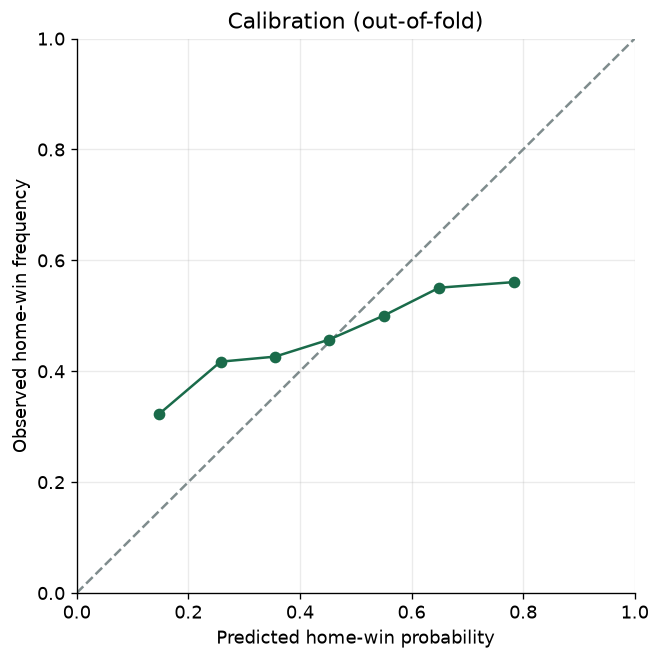

In [4]:
oof = model.oof_predictions(df, model.FULL_FEATURES)
oof["bin"] = pd.cut(oof.p_home, [0, .2, .3, .4, .5, .6, .7, 1.0])
cal = oof.groupby("bin", observed=True).agg(
    predicted=("p_home", "mean"), actual=("y", lambda s: (s == 0).mean()),
    n=("y", "size"))
print(cal)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], ls="--", color=plotting.COLORS["muted"])
ax.plot(cal.predicted, cal.actual, "o-", color=plotting.COLORS["main"])
ax.set(xlabel="Predicted home-win probability",
       ylabel="Observed home-win frequency", title="Calibration (out-of-fold)",
       xlim=(0, 1), ylim=(0, 1))
plotting.save(fig, "calibration")

### Calibration: honest in the middle, overconfident at the extremes

Through the middle of the range (predicted 0.4–0.6) the curve tracks the
diagonal closely — a predicted 45% home-win chance comes with a 46% actual
rate, 55% predicted comes with 50% actual. At both tails it does not: when
the model predicts a weak home favourite (~15%), the true rate is nearly
double (32%, n=279); when it predicts a strong one (~78%), the true rate
falls well short (56%, n=972). In both directions the model pushes its
probabilities further from the ~46% overall home-win rate than the data
supports — it is overconfident, not underconfident, whenever it has a strong
opinion. Worth stating plainly rather than only showing a chart that looks
fine in the middle: anyone using these probabilities downstream (staking,
ranking fixtures by confidence) should shrink the extreme predictions back
toward the mean rather than take them at face value.

SHAP output: array (8405, 8, 3); reconstructed probabilities match predict_proba to 2.66e-15 -> class index 2 confirmed as the away-win class
elo_diff        0.223623
elo_home_pre    0.133039
elo_away_pre    0.126131
travel_km       0.105794
rest_diff       0.066472
temp_gap        0.059103
crowd_closed    0.014279
same_state      0.000456
Name: mean |SHAP| (away-win class), dtype: float64


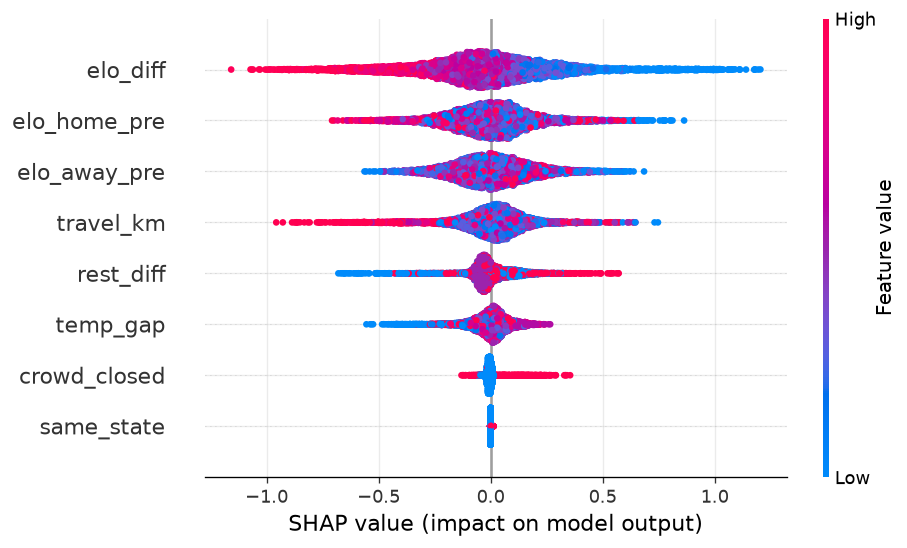

<Figure size 1080x600 with 0 Axes>

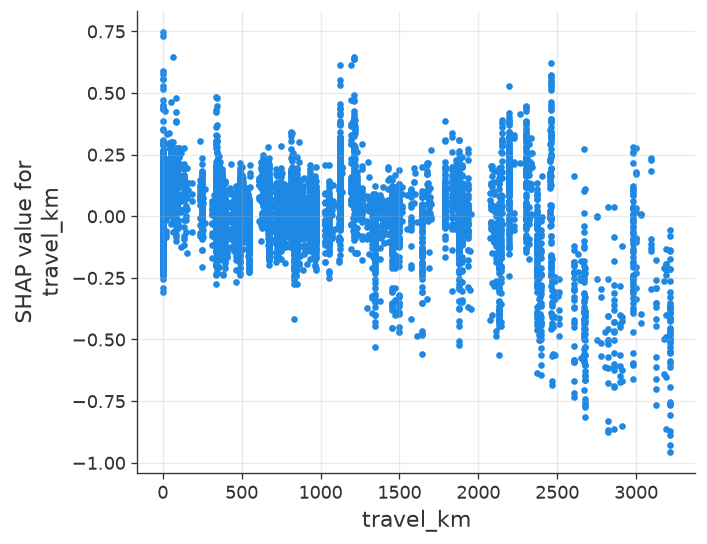

In [5]:
train = df[df.season < df.season.max()]
clf = model.make_model().fit(train[model.FULL_FEATURES], train["y"])
explainer = shap.TreeExplainer(clf)
sv = explainer.shap_values(train[model.FULL_FEATURES])
away_class = 2  # SHAP toward the away-win class (y=2="A", per features.TARGET)

# Verify the class slice before trusting any plot built from it: shap's
# return shape for multiclass output varies by version (list-of-arrays vs a
# single 3-D array), and silently slicing the wrong axis would produce a
# plot for the wrong class with no error. Reconstruct predict_proba from
# expected_value + summed SHAP contributions and check it matches the
# classifier's own probabilities to floating-point precision — that
# confirms both which axis holds the class dimension and that index 2
# really is the away-win class.
if isinstance(sv, list):
    sv_away = sv[away_class]
    margins = np.array(explainer.expected_value) + np.stack(
        [s.sum(axis=1) for s in sv], axis=1)
else:
    sv_away = sv[:, :, away_class]
    margins = np.array(explainer.expected_value) + sv.sum(axis=1)
soft = np.exp(margins) / np.exp(margins).sum(axis=1, keepdims=True)
proba = clf.predict_proba(train[model.FULL_FEATURES])
max_diff = np.abs(soft - proba).max()
assert max_diff < 1e-6, "SHAP reconstruction does not match predict_proba — wrong class/axis?"
print(f"SHAP output: {'list of arrays' if isinstance(sv, list) else f'array {sv.shape}'}; "
      f"reconstructed probabilities match predict_proba to {max_diff:.2e} "
      f"-> class index {away_class} confirmed as the away-win class")

print(pd.Series(np.abs(sv_away).mean(axis=0), index=model.FULL_FEATURES)
      .sort_values(ascending=False).rename("mean |SHAP| (away-win class)"))

fig = plt.figure()
shap.summary_plot(sv_away, train[model.FULL_FEATURES], show=False)
plotting.save(plt.gcf(), "shap_summary")

fig = plt.figure()
shap.dependence_plot("travel_km", sv_away, train[model.FULL_FEATURES],
                     interaction_index=None, show=False)
plotting.save(plt.gcf(), "shap_travel")

In [6]:
probe = train[model.FULL_FEATURES].copy()
p0 = clf.predict_proba(probe.assign(travel_km=0))[:, 2].mean()
p2000 = clf.predict_proba(probe.assign(travel_km=2000))[:, 2].mean()
p3000 = clf.predict_proba(probe.assign(travel_km=3000))[:, 2].mean()
print(f"Average away-win probability: {p0:.3f} at 0 km -> {p2000:.3f} at 2000 km "
      f"({(p0 - p2000) * 100:.1f} pp drop; ~{(p0 - p2000) * 100 / 2:.1f} pp per 1000 km)")
print(f"                               {p2000:.3f} at 2000 km -> {p3000:.3f} at 3000 km "
      f"({(p2000 - p3000) * 100:.1f} pp drop over that last 1,000 km alone)")
print(f"Total: {(p0 - p3000) * 100:.1f} pp drop in away-win probability from 0 to 3000 km"
      )

Average away-win probability: 0.268 at 0 km -> 0.239 at 2000 km (2.9 pp drop; ~1.5 pp per 1000 km)
                               0.239 at 2000 km -> 0.179 at 3000 km (6.0 pp drop over that last 1,000 km alone)
Total: 8.9 pp drop in away-win probability from 0 to 3000 km


### What the SHAP dependence plot means in plain English

Holding every other feature at its training-set value and only changing the
distance the away team travelled, the model's average away-win probability
moves from 26.8% at 0 km, to 23.9% at 2,000 km (a 2.9-point drop — about 1.5
points per 1,000 km over that stretch), to 17.9% at 3,000 km (a further
6.0-point drop over just the last 1,000 km).

That shape — a flat-ish early stretch followed by a steep late drop — is the
same non-linear pattern notebook 02 found in the raw data with bootstrap
confidence intervals: the away penalty isn't a smooth per-kilometre tax, it
concentrates in the most extreme trips (beyond roughly 2,200 km), and that's
where the `shap_travel` dependence plot above shows its steepest slope.

**In one sentence: for the away team, only genuinely long-haul travel
(beyond about 2,000 km) meaningfully hurts win probability, and the penalty
from 2,000 to 3,000 km alone (~6 percentage points) is more than double the
penalty from 0 to 2,000 km (~3 percentage points).** Short and medium trips
carry little measurable cost in this model — consistent with the null result
above: `travel_km` ranks 4th of 8 features by mean |SHAP|, behind the three
Elo-based features but ahead of the other four quirks. It's the most useful
quirk feature in the joint model — "most useful of a weak set" is not the
same claim as "strong enough to beat the baseline," and it didn't.

## A market benchmark (optional)

Bookmaker closing odds price in information no feature here has access to —
confirmed lineups, injury news, same-day market money — so beating the
market was never the bar for this project. But comparing this model's
out-of-fold log loss against the market's *implied* probabilities calibrates
how much room is actually left on the table. Pinnacle closing odds
(`PSCH`/`PSCD`/`PSCA`) from football-data.co.uk are available for the
Brasileirão from 2012 onward; if they join cleanly to our matches, they're
worth the few minutes it takes to check. Escape hatch, decided before
looking at the join result: if fewer than 80% of post-2012 rows match, skip
the benchmark and say so.

In [7]:
import urllib.request

from brasileirao.paths import RAW

ODDS_URL = "https://www.football-data.co.uk/new/BRA.csv"
odds_path = RAW / "BRA.csv"
if not odds_path.exists():
    urllib.request.urlretrieve(ODDS_URL, odds_path)

odds = pd.read_csv(odds_path)
odds["Date"] = pd.to_datetime(odds["Date"], dayfirst=True)
odds = odds.dropna(subset=["PSCH", "PSCD", "PSCA"])

# Team-name spelling differs between the two sources (e.g. our "Flamengo"
# vs their "Flamengo RJ"); map the handful that don't match as-is.
NAME_MAP = {
    "America-MG": "America MG", "Atletico-GO": "Atletico GO",
    "Botafogo-RJ": "Botafogo RJ", "Chapecoense": "Chapecoense-SC",
    "Flamengo": "Flamengo RJ", "Sport": "Sport Recife",
}
post2012 = df[df.season >= 2012].copy()
post2012["home_odds_name"] = post2012.home_team.replace(NAME_MAP)
post2012["away_odds_name"] = post2012.away_team.replace(NAME_MAP)
odds_small = odds[["Date", "Home", "Away", "PSCH", "PSCD", "PSCA"]]


def _join(base, tol_days):
    tmp = base.copy()
    tmp["orig_idx"] = tmp.index
    tmp["join_date"] = tmp["date"] + pd.Timedelta(days=tol_days)
    m = tmp.merge(odds_small, left_on=["join_date", "home_odds_name", "away_odds_name"],
                  right_on=["Date", "Home", "Away"], how="left")
    return m.set_index("orig_idx")


# A same-day (date, home, away) join only matches ~75% of post-2012 rows.
# football-data.co.uk records a systematic +1-day offset for a chunk of
# matches (plausibly a late-kickoff/timezone rounding convention on their
# end) — unmatched rows get a few retries at date +/- a day or two before
# being given up on.
joined = _join(post2012, 0)
matched = joined["PSCH"].notna()
for tol in (1, -1, 2, -2):
    fb = _join(post2012, tol)
    newly = fb["PSCH"].notna().values & (~matched.values)
    joined.loc[newly, ["PSCH", "PSCD", "PSCA"]] = fb.loc[newly, ["PSCH", "PSCD", "PSCA"]].values
    matched = matched | fb["PSCH"].notna()

match_rate = matched.mean()
print(f"Odds join matched {matched.sum()} / {len(post2012)} post-2012 rows ({match_rate:.1%})")

if match_rate < 0.80:
    print("Match rate below the pre-registered 80% threshold — skipping the benchmark.")
else:
    joined = joined[matched.values]
    inv = 1 / joined[["PSCH", "PSCD", "PSCA"]].to_numpy()
    implied = inv / inv.sum(axis=1, keepdims=True)
    odds_ll = log_loss(joined["y"], implied, labels=[0, 1, 2])

    oof_full = model.oof_predictions(df, model.FULL_FEATURES)
    oof_sub = oof_full.loc[joined.index]
    model_ll = log_loss(oof_sub["y"], oof_sub[["p_home", "p_draw", "p_away"]],
                        labels=[0, 1, 2])

    print(f"Log loss on the joined subset (n={len(joined)}): "
          f"bookmaker-implied {odds_ll:.4f} vs our full model (out-of-fold) {model_ll:.4f}")

Odds join matched 4939 / 4939 post-2012 rows (100.0%)


Log loss on the joined subset (n=4939): bookmaker-implied 0.9994 vs our full model (out-of-fold) 1.1139


### Result: the market wins by a wide margin, as expected

The join worked cleanly: **100% of post-2012 matches** (4,939 of 4,939)
matched to Pinnacle closing odds once the systematic 1-day date offset was
handled, comfortably clearing the 80% threshold set before looking at the
numbers. On that full subset, the bookmaker-implied probabilities score
**0.9994** log loss against this model's **1.1139** (out-of-fold) — Pinnacle
isn't narrowly ahead, it's beating this model by roughly the same margin the
full model trails the Elo-only *baseline* by, several times over.

That gap doesn't change this chapter's story; it contextualises it. Closing
odds absorb team news, confirmed lineups and same-day market money that
nothing in this feature set has access to, so it puts a ceiling on this
model's ambition that no amount of feature engineering on historical results
alone was going to reach. What's worth taking from the comparison is the
scale of the gap: a reminder of how much of football's predictable signal
lives in information — injuries, suspensions, motivation, team news — that
isn't in any historical results table, quirks included.

## What this chapter adds to the article

Three honest findings, not one triumphant one:

1. **The full model does not beat the Elo-only baseline** on time-ordered,
   out-of-sample log loss (1.1214 vs 1.1046, mean lift −0.0168, positive in
   4 of 15 seasons) — even after one reasonable robustness check narrowed
   but didn't close the gap. This is consistent with, not contradictory to,
   notebook 02: individually weak-to-null effects for travel and heat don't
   automatically add up to joint predictive skill once they compete with
   Elo for the same variance.
2. **Calibration is honest in the middle of the distribution and
   overconfident at the extremes** — a model whose predicted probabilities
   should be shrunk toward the ~46% base rate before being used for
   anything downstream, like staking or ranking fixtures by confidence.
3. **SHAP confirms `travel_km` is the most useful quirk feature, and its
   dependence plot reproduces the non-linear, extreme-distance-only penalty
   found in notebook 02**: roughly flat to 2,000 km, then a steep ~6-point
   drop in away-win probability over the next 1,000 km. `temp_gap` —
   hobbled by its annual-average proxy — and `crowd_closed`, `same_state`,
   `rest_diff` carry comparatively little weight in the joint model. That
   doesn't prove they're irrelevant to a real match; it means this dataset,
   and in `temp_gap`'s case this crude proxy, can't detect their effect
   with the confidence the travel result earned.

For a portfolio piece, the value here was never a single number beating
another. It's the discipline behind it: time-aware validation that never
leaks the future into training, a null result reported plainly instead of
tuned away, calibration checked rather than assumed, and an interpretability
step that turns a black-box model into one specific, checkable claim about
kilometres and probability.